# Week 15 Exercises

## 1 Predator Prey equations

$ \frac{dx}{dt} = x(1-x)-\frac{axy}{d+x} $

$ \frac{dy}{dt} = by(1-\frac{y}{x}) $

for $ a = 1, d = 0.1, b\in [0.1,0.5] $ 

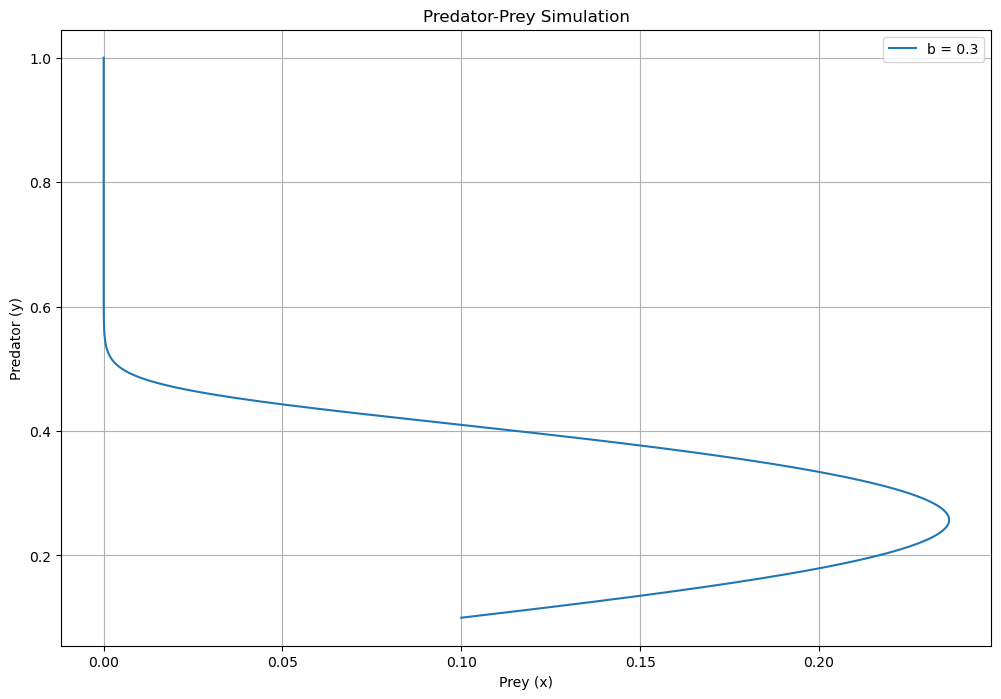

In [30]:
# Simulate the predator prey equations

import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 1
d = 0.1
b = 0.3
T = 100
dt = 0.01
numsteps = int(T/dt)

def predpreysim(b):
    x = 0.1
    y = 0.1

    xvals = [x]
    yvals = [y]

    for _ in range(numsteps):
        dx_dt = x * (1 - x) - a * x * y / (d + x)
        dy_dt = b * y * (1 - y)    

        x += dx_dt * dt
        y += dy_dt * dt

        x = max(0, min(1, x))
        y = max(0, min(1, y))

        xvals.append(x)
        yvals.append(y)

    return xvals, yvals

plt.figure(figsize=(12, 8))

x_values, y_values = predpreysim(b)
plt.plot(x_values, y_values, label=f'b = {b}') 

plt.title('Predator-Prey Simulation')
plt.xlabel('Prey (x)')
plt.ylabel('Predator (y)')
plt.legend()
plt.grid(True)
plt.show()

            

In [31]:
import scipy.optimize as opt

def preyderivative(x,y):
    return x * (1-x) - a * x * y / (d+x)

# Find Phase condition
def findphase(b):
    # Function to find root
    def rootfunc(x):
        return preyderivative(x, opt.fsolve(lambda y: b*y*(1-y), 0.5)[0])
    
    x_guess = 0.4
    return opt.fsolve(rootfunc, x_guess)[0]

# Find the phase condition for each b
phase_conds = [findphase(b)]
print(phase_conds)



[0.39821528763429076]


In [32]:
# Construct the shooting[3] root-finding problem[4] for the predator-prey example; check that it can find the periodic orbit found in 1.


